# Mejoras — Intención: Fine-tuning BETO v2 y análisis de fusión de clases

Continúa de `Mejoras_Intencion_Preprocesamiento.ipynb`. Aquí se documenta:
(1) el fine-tuning de BETO sobre el corpus v2 (puntuación/tildes corregidas),
(2) el análisis de si conviene fusionar alguna de las 8 clases de intención, y
(3) la decisión final sobre la regla de negocio de urgencia.

## 1. Fine-tuning de BETO sobre el corpus v2

Se parte del checkpoint **base** (no del ya afinado con las 296 muestras
originales), para no reforzar el sesgo de puntuación ya detectado.

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "..", "data")
MODELOS_DIR = os.path.join(BASE_DIR, "app", "modelos")
FIGURAS_DIR = os.path.join(BASE_DIR, "resultados", "figuras")
RANDOM_STATE = 42
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"

df_v2 = pd.read_csv(os.path.join(DATA_DIR, "intenciones_dataset_v2.csv"))
le = LabelEncoder()
df_v2["label"] = le.fit_transform(df_v2["intencion"])

train_df, dev_df = train_test_split(df_v2, test_size=0.15, stratify=df_v2["label"], random_state=RANDOM_STATE)
print(f"Corpus v2: {len(df_v2)} mensajes. Train: {len(train_df)}  Dev: {len(dev_df)}  Clases: {len(le.classes_)}")


Corpus v2: 564 mensajes. Train: 479  Dev: 85  Clases: 8


In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["texto"], truncation=True, padding="max_length", max_length=48)

train_ds = Dataset.from_pandas(train_df[["texto", "label"]]).map(tokenize, batched=True)
dev_ds = Dataset.from_pandas(dev_df[["texto", "label"]]).map(tokenize, batched=True)

modelo_beto_v2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(le.classes_))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds), "f1_macro": f1_score(labels, preds, average="macro")}

args = TrainingArguments(
    output_dir="_ckpt_tmp", num_train_epochs=10, per_device_train_batch_size=16,
    per_device_eval_batch_size=32, learning_rate=2e-5, fp16=True,
    eval_strategy="epoch", save_strategy="no", logging_strategy="epoch",
    report_to=[], seed=RANDOM_STATE,
)
trainer = Trainer(
    model=modelo_beto_v2, args=args, train_dataset=train_ds, eval_dataset=dev_ds,
    processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
trainer.train()


Map:   0%|          | 0/479 [00:00<?, ? examples/s]

Map:   0%|          | 0/85 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.789981,1.249454,0.811765,0.815373
2,0.900516,0.531356,0.929412,0.931659
3,0.346746,0.255398,0.941176,0.939101
4,0.134121,0.114238,0.964706,0.963752
5,0.044946,0.052983,0.988235,0.986068
6,0.022014,0.034408,0.988235,0.986068
7,0.015060,0.026780,0.988235,0.986068
8,0.012771,0.030518,0.988235,0.986068
9,0.011429,0.029677,0.988235,0.986068
10,0.010937,0.029636,0.988235,0.986068


TrainOutput(global_step=300, training_loss=0.3288521371285121, metrics={'train_runtime': 30.0824, 'train_samples_per_second': 159.23, 'train_steps_per_second': 9.973, 'total_flos': 118159673402880.0, 'train_loss': 0.3288521371285121, 'epoch': 10.0})

In [3]:
historia = [log for log in trainer.state.log_history if "eval_f1_macro" in log]
df_hist = pd.DataFrame(historia)[["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]]
train_losses = [log["loss"] for log in trainer.state.log_history if "loss" in log and "eval_loss" not in log]
df_hist["train_loss"] = train_losses[:len(df_hist)]
df_hist = df_hist[["epoch", "train_loss", "eval_loss", "eval_accuracy", "eval_f1_macro"]]
df_hist.to_csv(os.path.join(BASE_DIR, "resultados", "tablas", "historia_entrenamiento_beto_fonazo_v2.csv"), index=False)
df_hist


,epoch,train_loss,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,1.789981,1.249454,0.811765,0.815373
1,2.0,0.900516,0.531356,0.929412,0.931659
2,3.0,0.346746,0.255398,0.941176,0.939101
3,4.0,0.134121,0.114238,0.964706,0.963752
4,5.0,0.044946,0.052983,0.988235,0.986068
5,6.0,0.022014,0.034408,0.988235,0.986068
6,7.0,0.015060,0.026780,0.988235,0.986068
7,8.0,0.012771,0.030518,0.988235,0.986068
8,9.0,0.011429,0.029677,0.988235,0.986068
9,10.0,0.010937,0.029636,0.988235,0.986068


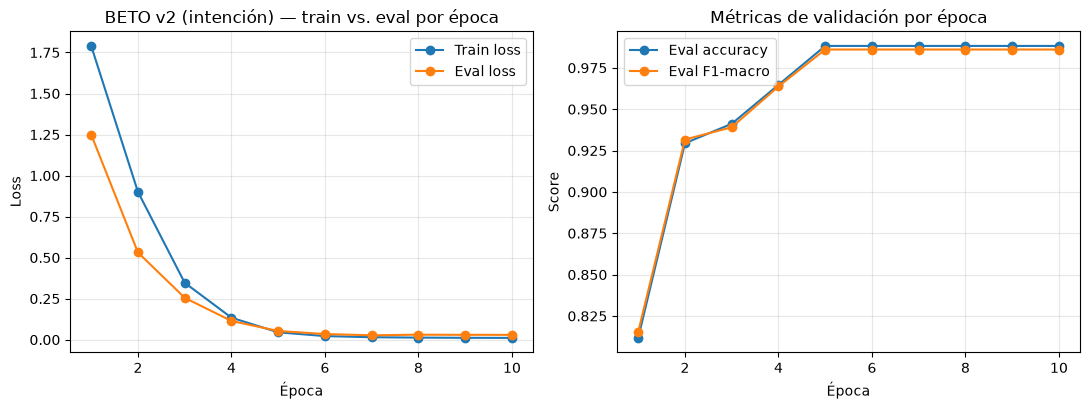

Guardado: fig24_curva_entrenamiento_beto_fonazo_v2.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(df_hist["epoch"], df_hist["train_loss"], marker="o", label="Train loss")
axes[0].plot(df_hist["epoch"], df_hist["eval_loss"], marker="o", label="Eval loss")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].set_title("BETO v2 (intención) — train vs. eval por época")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_hist["epoch"], df_hist["eval_accuracy"], marker="o", label="Eval accuracy")
axes[1].plot(df_hist["epoch"], df_hist["eval_f1_macro"], marker="o", label="Eval F1-macro")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Score")
axes[1].set_title("Métricas de validación por época")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig24_curva_entrenamiento_beto_fonazo_v2.png"), dpi=150)
plt.show()
print("Guardado: fig24_curva_entrenamiento_beto_fonazo_v2.png")


> **Nota de rigor:** el corpus v2 contiene variantes de la misma frase base
> (con/sin `¿`, con/sin tildes). Al hacer el split train/dev al azar, dos
> variantes de la misma frase pueden caer una en cada lado — eso infla la
> métrica de `eval` por época (fuga de datos leve). Por eso el juicio real de
> este modelo viene de la validación externa de la siguiente sección, sobre
> el set de 80 mensajes que nunca participó del entrenamiento.

In [5]:
OUT_DIR = os.path.join(MODELOS_DIR, "beto_fonazo_v2")
os.makedirs(OUT_DIR, exist_ok=True)
modelo_beto_v2.save_pretrained(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)
joblib.dump(le, os.path.join(OUT_DIR, "label_encoder.joblib"))
print(f"Modelo guardado en {OUT_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en D:\TF_Aplicaciones_DataScience\repo\code\app\modelos\beto_fonazo_v2


## 2. Validación externa (80 mensajes, fuera de plantilla)

In [6]:
DATOS_EXTERNOS = [
    ("buenas, el airpods pro viene con estuche de carga inalambrica", "consulta_producto"),
    ("oe manito el ipad mini lo tienen en gris espacial", "consulta_producto"),
    ("quisiera saber si el apple watch se puede usar sin el iphone", "consulta_producto"),
    ("el macbook air m2 lo tienen disponible en tienda", "consulta_producto"),
    ("hola, necesito saber si el case tiene proteccion para camara", "consulta_producto"),
    ("disculpa, la mica que venden es de vidrio templado o plastico", "consulta_producto"),
    ("el cargador que ofrecen es original de apple o generico", "consulta_producto"),
    ("amigo tienen fundas de cuero para el iphone 15", "consulta_producto"),
    ("el iphone que venden viene con caja sellada", "consulta_producto"),
    ("buenas noches, cuentan con el modelo se en color rojo", "consulta_producto"),
    ("cuanto sale el combo de mica mas case", "consulta_precio"),
    ("que precio tiene el airpods pro 2da generacion", "consulta_precio"),
    ("tienen descuento si pago en efectivo", "consulta_precio"),
    ("cuanto cuesta el cambio de bateria del iphone 12", "consulta_precio"),
    ("cual es el precio del cargador magsafe original", "consulta_precio"),
    ("cuanto me costaria llevar dos micas", "consulta_precio"),
    ("hacen rebaja por black friday", "consulta_precio"),
    ("cuanto vale el macbook reacondicionado", "consulta_precio"),
    ("el precio incluye instalacion de la mica", "consulta_precio"),
    ("que costo tiene el servicio de diagnostico", "consulta_precio"),
    ("mi iphone se calienta mucho, podrian revisarlo", "consulta_servicio_tecnico"),
    ("el altavoz de mi cel casi no se escucha, que puede ser", "consulta_servicio_tecnico"),
    ("tienen servicio de cambio de bateria a domicilio", "consulta_servicio_tecnico"),
    ("mi ipad no carga bien, ustedes lo revisan", "consulta_servicio_tecnico"),
    ("cuanto demora el diagnostico de un macbook", "consulta_servicio_tecnico"),
    ("mi apple watch no enciende, tiene solucion", "consulta_servicio_tecnico"),
    ("hacen reparacion de placas o solo cambian pantallas", "consulta_servicio_tecnico"),
    ("mi telefono se moja un poco, aun se puede salvar", "consulta_servicio_tecnico"),
    ("el boton de encendido de mi cel esta fallando, lo arreglan", "consulta_servicio_tecnico"),
    ("tienen garantia despues de la reparacion", "consulta_servicio_tecnico"),
    ("la funda que compre se rompio a la semana, que mal", "queja_producto_servicio"),
    ("el audio de los airpods que me vendieron sale con estatica", "queja_producto_servicio"),
    ("me entregaron el pedido sin los accesorios completos", "queja_producto_servicio"),
    ("el vidrio templado que instalaron quedo con burbujas", "queja_producto_servicio"),
    ("el tecnico me devolvio el cel con un rayon nuevo", "queja_producto_servicio"),
    ("compre el cargador y ya no carga como deberia", "queja_producto_servicio"),
    ("el color del case no es el que pedi", "queja_producto_servicio"),
    ("la reparacion que me hicieron duro solo dos dias", "queja_producto_servicio"),
    ("me vendieron un producto usado como si fuera nuevo", "queja_producto_servicio"),
    ("el servicio que recibi fue muy descuidado", "queja_producto_servicio"),
    ("puedo cambiar el case porque no es el modelo correcto", "solicitud_garantia_cambio"),
    ("la mica se rompio sola, aplica para cambio por garantia", "solicitud_garantia_cambio"),
    ("quiero devolver el cargador porque no sirve", "solicitud_garantia_cambio"),
    ("me pueden cambiar el producto por otro de otro color", "solicitud_garantia_cambio"),
    ("el audifono izquierdo no suena, tiene cambio", "solicitud_garantia_cambio"),
    ("compre hace tres dias y ya quiero el reembolso", "solicitud_garantia_cambio"),
    ("la funda vino defectuosa, la puedo canjear", "solicitud_garantia_cambio"),
    ("necesito hacer valido el cambio por producto malogrado", "solicitud_garantia_cambio"),
    ("el reloj no sincroniza, aplica garantia", "solicitud_garantia_cambio"),
    ("quiero el cambio del producto porque llego incompleto", "solicitud_garantia_cambio"),
    ("deje mi laptop el martes, ya esta lista", "seguimiento_reparacion"),
    ("cuanto falta para que terminen con mi reparacion", "seguimiento_reparacion"),
    ("llevo esperando una semana y no me avisan nada", "seguimiento_reparacion"),
    ("mi cel entro a servicio ayer, hay algun avance", "seguimiento_reparacion"),
    ("quisiera saber el estado de mi ipad en reparacion", "seguimiento_reparacion"),
    ("me dijeron que llame hoy para saber si esta listo", "seguimiento_reparacion"),
    ("cuando puedo recoger mi equipo", "seguimiento_reparacion"),
    ("aun no me llega ningun mensaje sobre mi reparacion", "seguimiento_reparacion"),
    ("el ticket de mi reparacion ya tiene respuesta", "seguimiento_reparacion"),
    ("quiero saber si ya encontraron el repuesto de mi cel", "seguimiento_reparacion"),
    ("esto ya es el tercer reclamo, necesito hablar con un supervisor", "escalamiento_urgente"),
    ("por favor pasenme con alguien que si pueda resolver esto", "escalamiento_urgente"),
    ("estoy realmente cansado de este maltrato, quiero una solucion ya", "escalamiento_urgente"),
    ("necesito que alguien se haga cargo de mi caso ahora mismo", "escalamiento_urgente"),
    ("ya no quiero hablar con el chat automatico, quiero una persona", "escalamiento_urgente"),
    ("esto es indignante, exijo hablar con el dueño del local", "escalamiento_urgente"),
    ("llevo horas esperando, comuniquenme con alguien responsable", "escalamiento_urgente"),
    ("necesito una respuesta inmediata de un encargado", "escalamiento_urgente"),
    ("esta situacion ya se me salio de las manos, necesito ayuda urgente", "escalamiento_urgente"),
    ("quiero presentar una queja formal con un supervisor ahora", "escalamiento_urgente"),
    ("buenas, siguen atendiendo a esta hora", "saludo_cierre"),
    ("hola, con quien tengo el gusto de hablar", "saludo_cierre"),
    ("muchas gracias por la info, eso era todo", "saludo_cierre"),
    ("perfecto, con eso me quedo tranquilo, gracias", "saludo_cierre"),
    ("buen dia, quisiera hacer una consulta rapida", "saludo_cierre"),
    ("listo, muchas gracias por su tiempo", "saludo_cierre"),
    ("hola buenas, ando averiguando unos productos", "saludo_cierre"),
    ("ya, entendido, muchas gracias", "saludo_cierre"),
    ("buenas noches, disculpen la hora", "saludo_cierre"),
    ("vale, gracias por la ayuda, que esten bien", "saludo_cierre"),
]
textos_ext = [t for t, _ in DATOS_EXTERNOS]
y_ext = [l for _, l in DATOS_EXTERNOS]
clases = sorted(set(y_ext))


BETO v2 (corpus con puntuación/tildes corregidas) — Accuracy=0.875  F1-macro=0.874


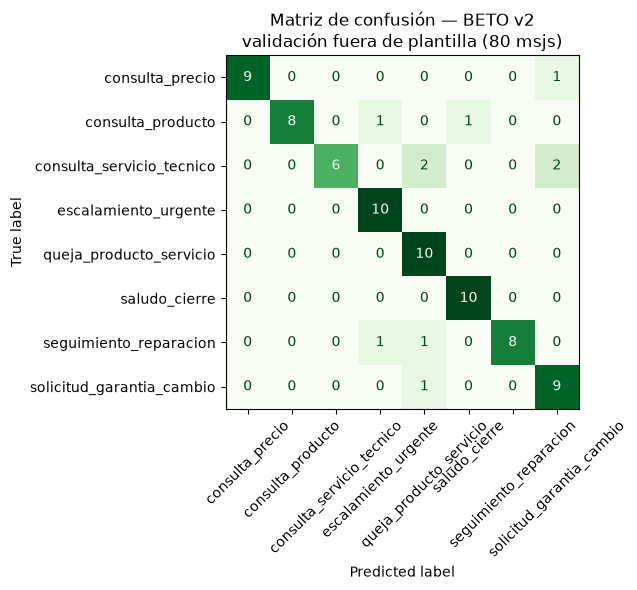

Guardado: fig25_matriz_confusion_beto_v2_fuera_plantilla.png


In [7]:
modelo_beto_v2.eval()
device = next(modelo_beto_v2.parameters()).device
y_pred_beto_v2 = []
with torch.no_grad():
    for t in textos_ext:
        inputs = tokenizer(t, truncation=True, padding="max_length", max_length=48, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        logits = modelo_beto_v2(**inputs).logits
        idx = int(torch.argmax(logits, dim=1)[0])
        y_pred_beto_v2.append(le.inverse_transform([idx])[0])

acc_beto_v2 = accuracy_score(y_ext, y_pred_beto_v2)
f1_beto_v2 = f1_score(y_ext, y_pred_beto_v2, average="macro")
cm_beto_v2 = confusion_matrix(y_ext, y_pred_beto_v2, labels=clases)
print(f"BETO v2 (corpus con puntuación/tildes corregidas) — Accuracy={acc_beto_v2:.3f}  F1-macro={f1_beto_v2:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_beto_v2, display_labels=clases)
disp.plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=45)
ax.set_title("Matriz de confusión — BETO v2\nvalidación fuera de plantilla (80 msjs)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig25_matriz_confusion_beto_v2_fuera_plantilla.png"), dpi=150)
plt.show()
print("Guardado: fig25_matriz_confusion_beto_v2_fuera_plantilla.png")
